In [2]:
%%capture

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

from astroquery.sdss import SDSS

In [3]:
sql = '''SELECT 
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
WHERE s.class = 'GALAXY' 
  AND s.snmedian_g > 10
  AND g.oiii_5007_eqw < -0.1
  AND g.nii_6584_eqw < -0.1
  AND g.h_beta_eqw < -0.1
  AND g.h_alpha_eqw < -0.1
  AND g.oiii_5007_flux > 5
  AND g.nii_6584_flux > 5
  AND g.h_beta_flux > 5
  AND g.h_alpha_flux > 5
  AND g.oiii_5007_flux > 3 * g.oiii_5007_flux_err
  AND g.nii_6584_flux > 3 * g.nii_6584_flux_err
  AND g.h_beta_flux > 3 * g.h_beta_flux_err
  AND g.h_alpha_flux > 3 * g.h_alpha_flux_err
  AND (2.355 * g.sigma_forbidden) < 500
  AND (2.355 * g.sigma_balmer) < 500'''

table = SDSS.query_sql(sql)

df_ful = table.to_pandas()

print(f"found {len(df_ful)} objects")

found 153231 objects


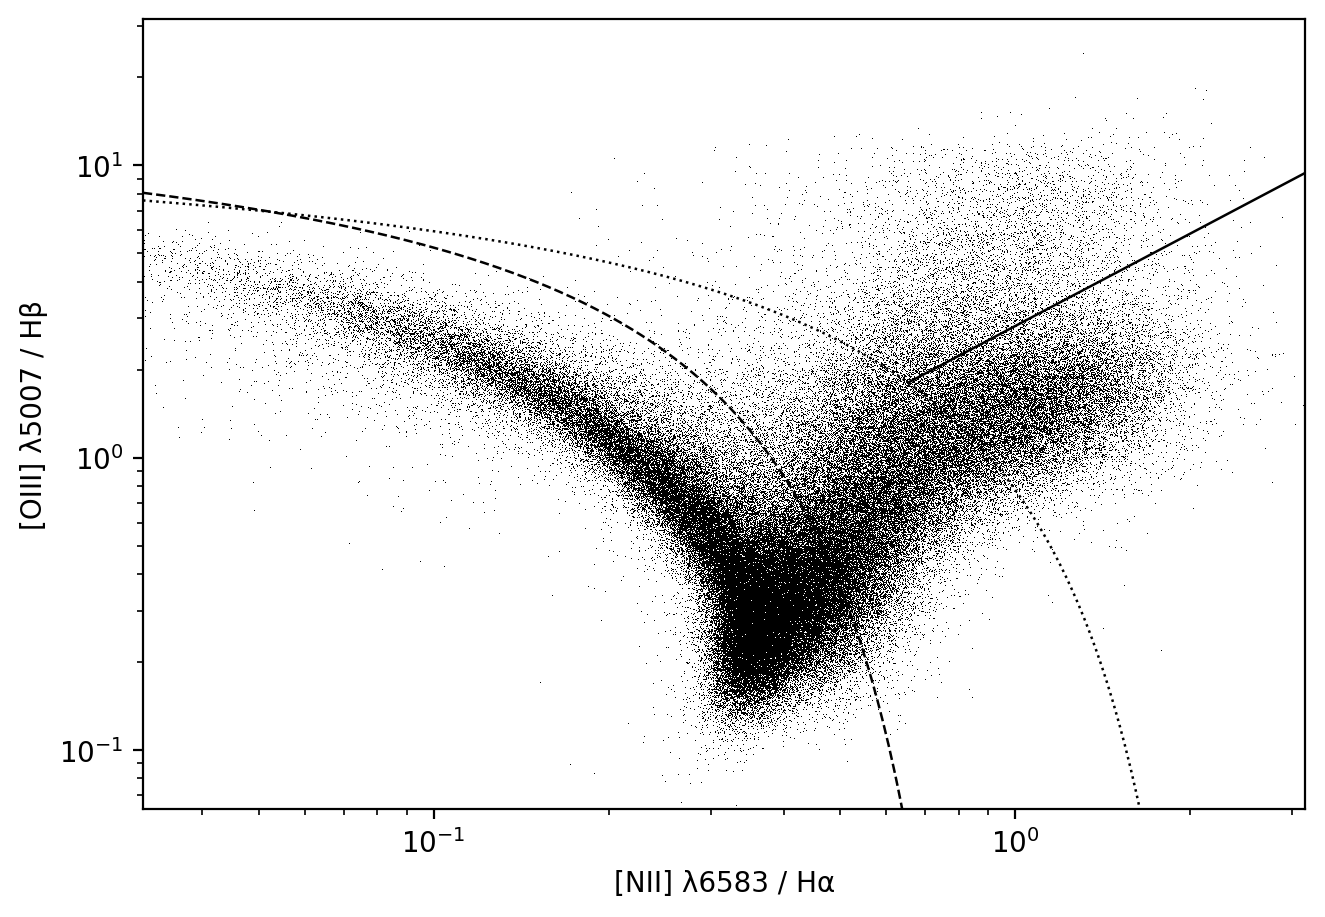

In [6]:
%config InlineBackend.figure_formats = ['retina']

x = np.logspace(-1.5, 0.5, 400)

y_kewl = 10**(0.61 / (np.log10(x) - 0.47) + 1.19)
y_kewl = y_kewl[x < 10**(0.47)]
x_kewl = x[x < 10**(0.47)]

y_kauf = 10**(0.61 / (np.log10(x) - 0.05) + 1.3)
y_kauf = y_kauf[x < 10**(0.05)]
x_kauf = x[x < 10**(0.05)]

y_scha = 10**(1.05 * np.log10(x) + 0.45)
x_scha = x[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]
y_scha = y_scha[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]

fig, ax = plt.subplots(1, 1, figsize=[7.5, 5.125])

ax.plot(df_ful['nii_halpha_ratio'], df_ful['oiii_hbeta_ratio'], 'k,')

ax.plot(x_kewl, y_kewl, 'k:', lw=0.9)
ax.plot(x_kauf, y_kauf, 'k--', lw=0.9)
ax.plot(x_scha, y_scha, 'k-', lw=0.9)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**(-1.5), 10**(0.5))
ax.set_ylim(10**(-1.2), 10**(1.5))

ax.set_xlabel('[NII] λ6583 / Hα')
ax.set_ylabel('[OIII] λ5007 / Hβ')

fig.savefig('bpt.png', dpi=600)

plt.show()
plt.close()

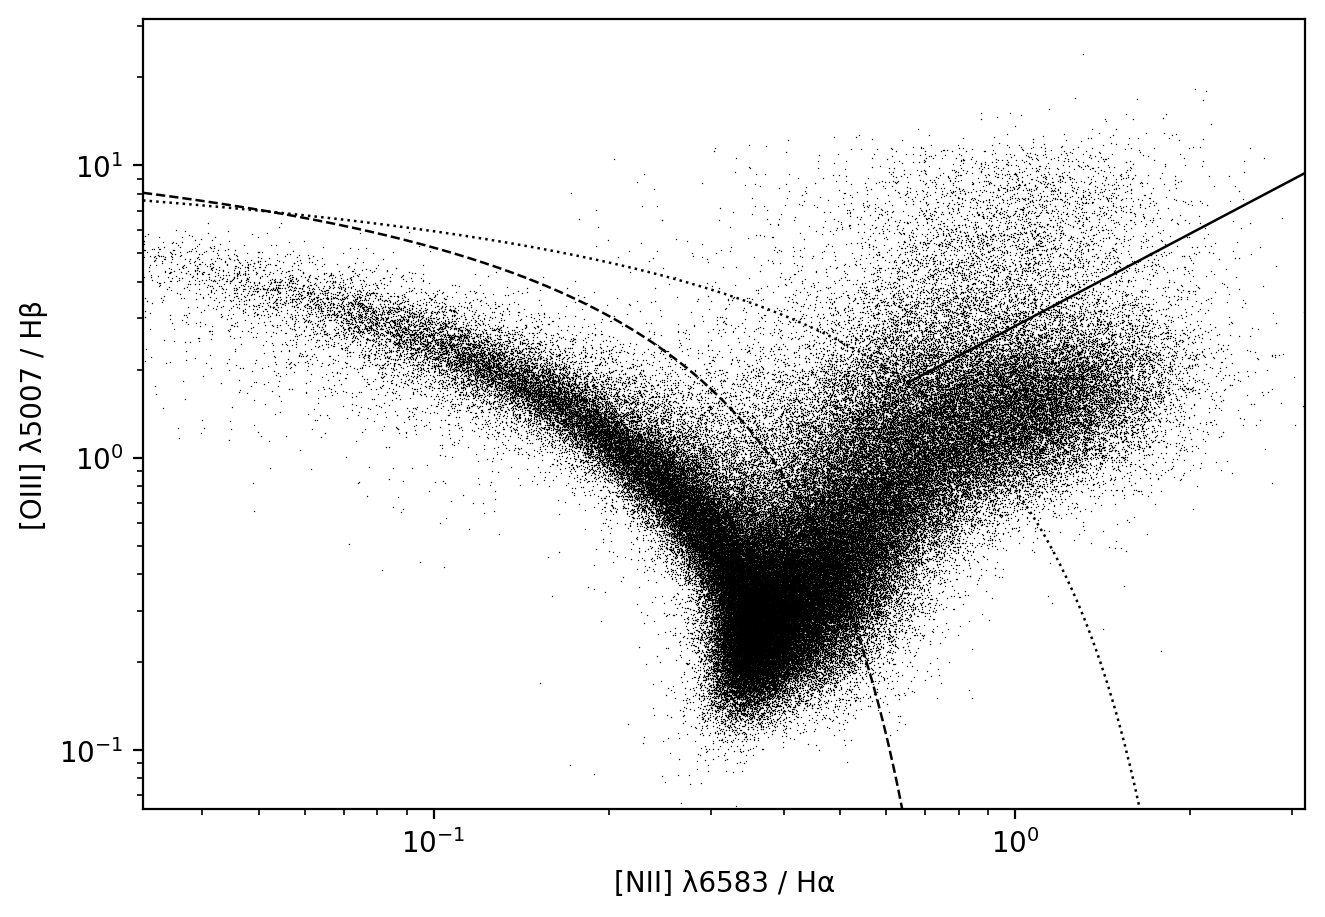

In [15]:
%config InlineBackend.figure_formats = ['retina']

x = np.logspace(-1.5, 0.5, 400)

y_kewl = 10**(0.61 / (np.log10(x) - 0.47) + 1.19)
y_kewl = y_kewl[x < 10**(0.47)]
x_kewl = x[x < 10**(0.47)]

y_kauf = 10**(0.61 / (np.log10(x) - 0.05) + 1.3)
y_kauf = y_kauf[x < 10**(0.05)]
x_kauf = x[x < 10**(0.05)]

y_scha = 10**(1.05 * np.log10(x) + 0.45)
x_scha = x[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]
y_scha = y_scha[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]

fig, ax = plt.subplots(1, 1, figsize=[7.5, 5.125])

ax.plot(df_ful['nii_halpha_ratio'], df_ful['oiii_hbeta_ratio'], 'o', ms=0.5, mec='none', mfc='black')

ax.plot(x_kewl, y_kewl, 'k:', lw=0.9)
ax.plot(x_kauf, y_kauf, 'k--', lw=0.9)
ax.plot(x_scha, y_scha, 'k-', lw=0.9)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**(-1.5), 10**(0.5))
ax.set_ylim(10**(-1.2), 10**(1.5))

ax.set_xlabel('[NII] λ6583 / Hα')
ax.set_ylabel('[OIII] λ5007 / Hβ')

fig.savefig('bpt.png', dpi=600)

plt.show()
plt.close()